<a href="https://colab.research.google.com/github/eddiejaques/ml-code-samples/blob/main/Security%20Breaches%20Dataset/data_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Security Data — Linear Regression

## Dataset
Data sourced from `security_data_10000.csv` (synthetic data generated from original class dataset).

| Column | Description |
|--------|-------------|
| Sector | Industry sector of the company |
| CEO_Gender | Gender of the CEO (Male/Female) |
| Size | Company size (Large, Medium, Small) |
| Security_Invest | Security investment amount |
| Security_Breach_Att | Number of security breach attempts |
| Succ_Sec_Breaches | Number of successful security breaches |
| Sec_Rating | Overall security rating (High/Medium/Low) |
| CEO_Sec_Exp | CEO's level of security experience (High/Medium/Low) |
| LOT_in_Business | Length of time in business (years) |
| Stock_Market | Whether the company is listed on the stock market (Yes/No) |

---

## Data Analysis Plan

1. **EDA** — Understand structure, summary statistics, and distributions
2. **Data Cleaning** — Check and handle missing/null values
3. **Outlier Detection** — Identify outliers using Isolation Forest
4. **Data Types** — Evaluate and encode categorical features
5. **Feature Scaling** — Apply standardization/normalization
6. **Correlation Analysis** — Understand feature relationships
7. **Train-Test Split** — Split dataset before any feature engineering
8. **Feature Engineering** — Apply transformations to both train and test sets
9. **Modelling** — Fit model, predict, and evaluate using MSE and R²

## Step 1 — Load Dataset

In [191]:
#LOAD THE DATASET


import pandas as pd

security_df = pd.read_csv("https://raw.githubusercontent.com/eddiejaques/ml-code-samples/refs/heads/main/Security%20Breaches%20Dataset/security-data.csv")

security_df.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
0,Banking,Female,Small,17,11,2,Medium,High,13,No
1,Banking,Male,Small,18,12,4,High,Low,9,No
2,Banking,Male,Small,17,12,4,High,Medium,22,No
3,Banking,Male,Small,24,13,1,High,Medium,3,Yes
4,Banking,Male,Small,32,14,3,High,Medium,4,Yes


## Step 2 — Train-Test Split
Split is performed **before** any feature engineering to prevent data leakage.

In [192]:
from sklearn.model_selection import train_test_split
security_df_train, security_df_test = train_test_split(security_df, test_size=0.2, random_state=42)


## Step 3 — Exploratory Data Analysis (EDA)

In [193]:
security_df_train.head()


,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
31,Hospitality,Male,Medium,91,184,85,Medium,High,21,Yes
3,Banking,Male,Small,24,13,1,High,Medium,3,Yes
52,Hospitality,Male,Large,87,77,33,Low,Medium,8,Yes
17,Health Care,Male,Small,27,20,8,High,High,4,Yes
8,Hospitality,Male,Small,99,77,34,Low,Medium,3,Yes


In [194]:
security_df_train.shape

(48, 10)

In [195]:
security_df_train.describe()


,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business
count,48.000000,48.000000,48.000000,48.000000
mean,66.604167,54.979167,24.229167,9.125000
std,75.107225,59.456220,24.295381,6.625627
min,12.000000,7.000000,0.000000,1.000000
25%,21.000000,16.250000,4.000000,3.000000
50%,32.000000,40.000000,19.000000,8.000000
75%,93.000000,77.000000,34.000000,14.000000
max,435.000000,321.000000,100.000000,22.000000


## Step 4 — Missing Value Check





In [186]:
security_df_train.isnull().sum()

,0
Sector,0
CEO_Gender,0
Size,0
Security_Invest,0
Security_Breach_Att,0
Succ_Sec_Breaches,0
Sec_Rating,0
CEO_Sec_Exp,0
LOT_in_Business,0
Stock_Market,0


There are no missing values within the dataset (within each column)

array([[<Axes: title={'center': 'Security_Invest'}>,
        <Axes: title={'center': 'Security_Breach_Att'}>],
       [<Axes: title={'center': 'Succ_Sec_Breaches'}>,
        <Axes: title={'center': 'LOT_in_Business'}>]], dtype=object)

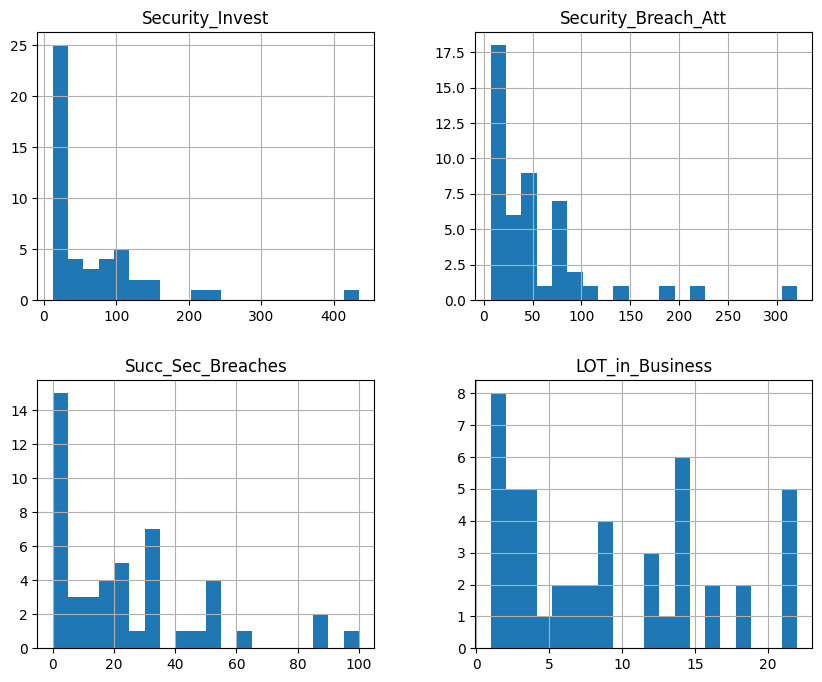

In [187]:
import matplotlib.pyplot as plt


security_df_train.hist(figsize=(10, 8), bins=20)

## Step 5 — Distribution & Outlier Check
Histograms show the distribution of each numeric feature.

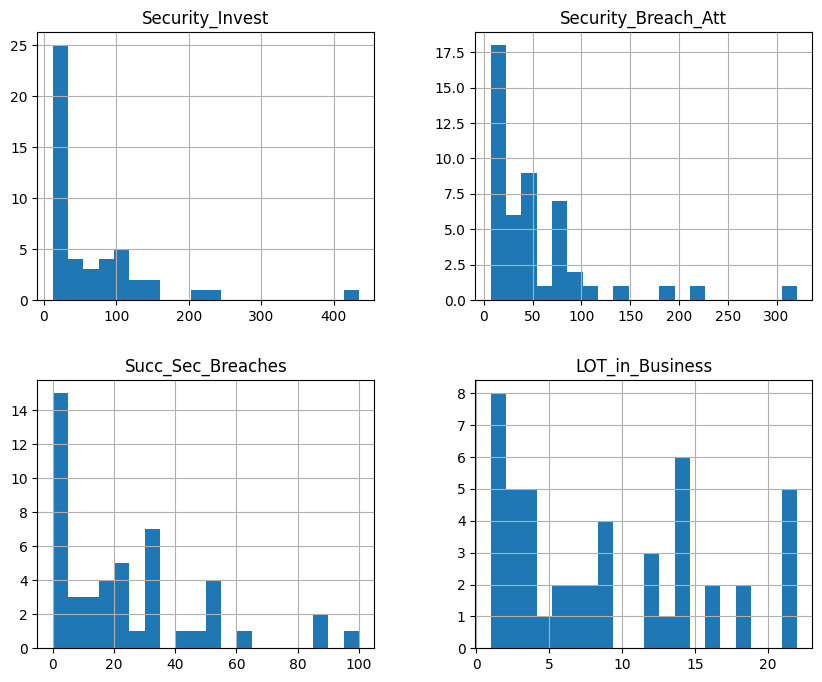

In [188]:
security_df_train.hist(figsize=(10, 8), bins=20)
plt.show()

No outliers that i can see. mostly independent variables left skewed.

In [189]:
print(security_df_train.shape)
print(security_df_test.shape)

(48, 10)
(12, 10)


,LOT_in_Business
LOT_in_Business,1.000000
Succ_Sec_Breaches,0.099875
Security_Breach_Att,0.036032
Security_Invest,-0.026236


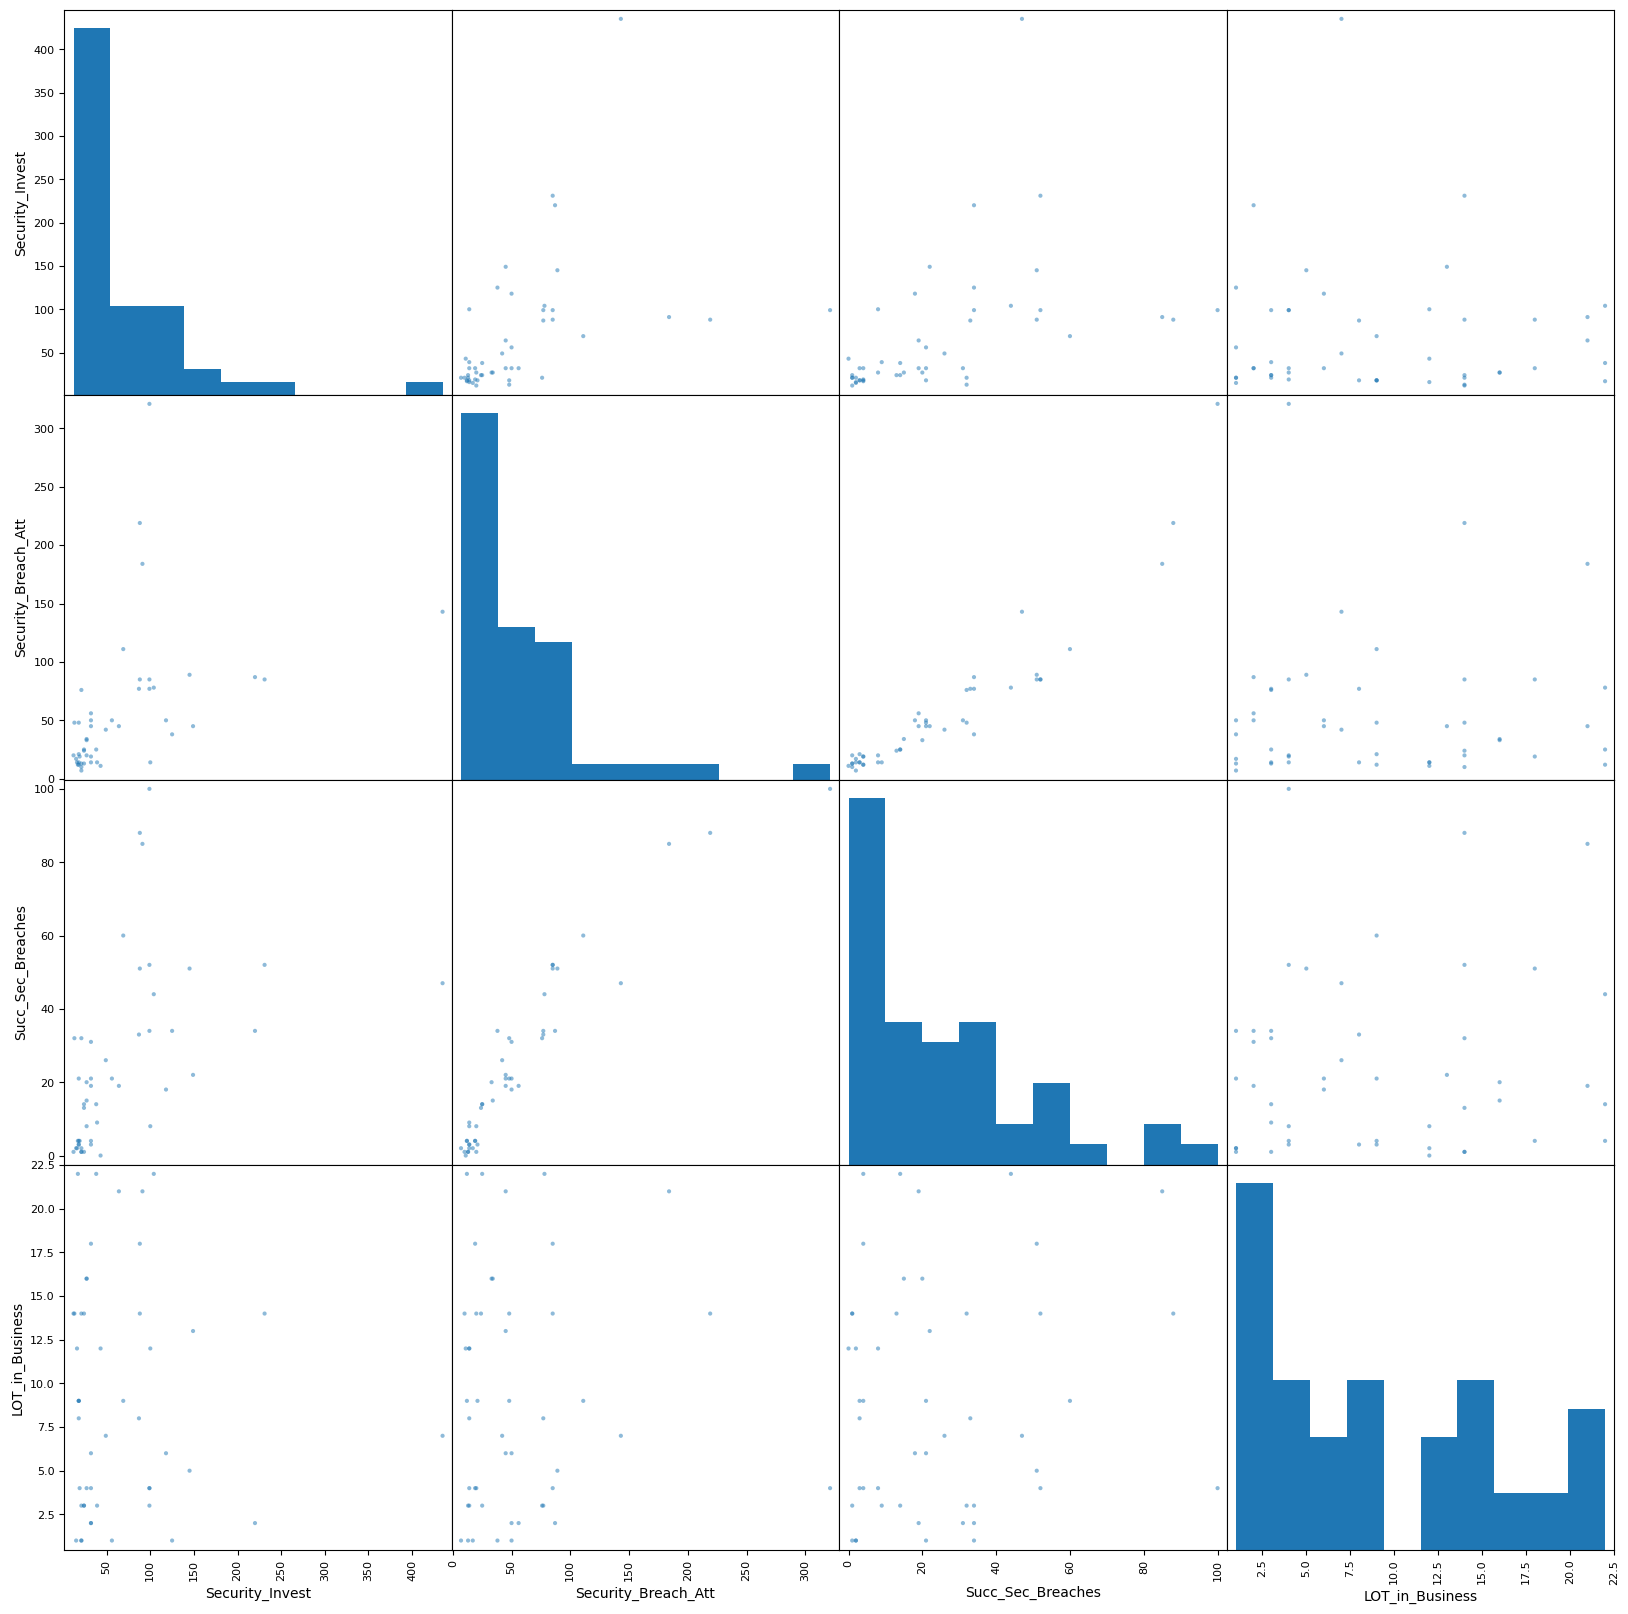

In [190]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

attributes = ["Security_Invest", "Security_Breach_Att", "Succ_Sec_Breaches",
              "LOT_in_Business"]
scatter_matrix(security_df_train[attributes], figsize=(20, 20))
#save_fig("scatter_matrix_plot")  # extra code

corr=security_df_train[attributes].corr()
corr["Security_Breach_Att"].sort_values(ascending=False)


corr["LOT_in_Business"].sort_values(ascending=False)


## Step 6 — Correlation Analysis
Scatter matrix and correlation coefficients to understand feature relationships.

No clear correlation between security investment and security breach attempts or successful breaches. There is a positive correlation between breach attempts and successful breaches, which is expected. No meaningful correlation found between length of time in business and breach attempts.

In [162]:
security_df_train_corr =  security_df_train[["Succ_Sec_Breaches","Security_Invest"]]

security_df_train_corr.corr()

,Succ_Sec_Breaches,Security_Invest
Succ_Sec_Breaches,1.000000,0.479426
Security_Invest,0.479426,1.000000


## Step 6b Create Target Labels

In [163]:
security_df_train_labels=security_df_train["Succ_Sec_Breaches"].copy()
security_df_train=security_df_train.drop("Succ_Sec_Breaches", axis=1)

security_df_test_labels=security_df_test["Succ_Sec_Breaches"].copy()
security_df_test  = security_df_test.drop("Succ_Sec_Breaches", axis=1)

In [164]:
numeric_cols = security_df_train.select_dtypes(include=[np.number]).columns
categorical_cols = security_df_train.select_dtypes(include=[object]).columns

print(numeric_cols)
print(categorical_cols)

print(security_df_train.shape)
print(security_df_test.shape)

Index(['Security_Invest', 'Security_Breach_Att', 'LOT_in_Business'], dtype='object')
Index(['Sector', 'CEO_Gender', 'Size', 'Sec_Rating', 'CEO_Sec_Exp',
       'Stock_Market'],
      dtype='object')
(48, 9)
(12, 9)


## Step 6c Impute

In [165]:
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy="median")

# Get numeric columns before imputation
numeric_cols_train = security_df_train.select_dtypes(include=[np.number]).columns
security_df_train_num = imputer.fit_transform(security_df_train.select_dtypes(include=[np.number]))

numeric_cols_test = security_df_test.select_dtypes(include=[np.number]).columns
security_df_test_num = imputer.transform(security_df_test.select_dtypes(include=[np.number]))

# Create DataFrames from imputed numeric arrays, preserving original indices
security_df_train_num_df = pd.DataFrame(security_df_train_num, columns=numeric_cols_train, index=security_df_train.index)
security_df_test_num_df = pd.DataFrame(security_df_test_num, columns=numeric_cols_test, index=security_df_test.index)

# Concatenate numeric and categorical parts
security_df_train = pd.concat([security_df_train_num_df, security_df_train[categorical_cols]], axis=1)
security_df_test = pd.concat([security_df_test_num_df, security_df_test[categorical_cols]], axis=1)

print(security_df_train.shape)
print(security_df_test.shape)

security_df_train.head()

(48, 9)
(12, 9)


,Security_Invest,Security_Breach_Att,LOT_in_Business,Sector,CEO_Gender,Size,Sec_Rating,CEO_Sec_Exp,Stock_Market
31,91.0,184.0,21.0,Hospitality,Male,Medium,Medium,High,Yes
3,24.0,13.0,3.0,Banking,Male,Small,High,Medium,Yes
52,87.0,77.0,8.0,Hospitality,Male,Large,Low,Medium,Yes
17,27.0,20.0,4.0,Health Care,Male,Small,High,High,Yes
8,99.0,77.0,3.0,Hospitality,Male,Small,Low,Medium,Yes


## Step 6d Remove Outliers

In [180]:
from sklearn.ensemble import IsolationForest
import pandas as pd # Ensure pandas is imported if not already globally available

# Re-load the original security_df to ensure we have the full dataset
# This is a precaution due to potential index/length mismatches from prior steps
# In a clean pipeline, this would not be needed, and labels would be kept in sync.
original_security_df = pd.read_csv("https://raw.githubusercontent.com/eddiejaques/ml-code-samples/refs/heads/main/Security%20Breaches%20Dataset/security-data.csv")

# Re-perform train-test split to get consistent original indices
from sklearn.model_selection import train_test_split
security_df_train_orig, _ = train_test_split(original_security_df, test_size=0.2, random_state=42)

# Re-extract labels ensuring original indices are maintained, then reset for alignment
security_df_train_labels = security_df_train_orig["Succ_Sec_Breaches"].copy().reset_index(drop=True)

# Ensure security_df_train itself has a RangeIndex for consistent filtering
# It should already have a RangeIndex if the previous FqSbViqRtWSQ fix was applied correctly
security_df_train = security_df_train.reset_index(drop=True)


isolation_forest = IsolationForest(random_state=42)

# Get numeric columns. Assuming numeric_cols is correctly defined from 3X9jL9DstgpR
# If not, you might need to re-run 3X9jL9DstgpR or define it here.
# For safety, let's redefine numeric_cols based on the current security_df_train
numeric_cols = security_df_train.select_dtypes(include=['number']).columns

outlier_pred = isolation_forest.fit_predict(security_df_train[numeric_cols])

# Filter both features and labels using the same boolean mask
security_df_train = security_df_train.iloc[outlier_pred == 1]
security_df_train_labels = security_df_train_labels.iloc[outlier_pred == 1]

print(security_df_train.shape)
print(security_df_test.shape)


IndexError: Boolean index has wrong length: 48 instead of 36

In [169]:
from sklearn.preprocessing import StandardScalar

scalar = StandardScaler()

security_df_train = scalar.fit_transform(security_df_train)
security_df_test = scalar.transform(security_df_test)





ImportError: cannot import name 'StandardScalar' from 'sklearn.preprocessing' (/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/__init__.py)

## Step 7 — Simple Linear Regression
**Question:** Can `Security_Invest` alone predict `Succ_Sec_Breaches`?

Simple linear regression uses **one independent variable** and **one dependent variable**.

In [ ]:
#simple linear regression

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(security_df_train[["Security_Invest"]], security_df_train["Succ_Sec_Breaches"])

security_df_train["Succ_Sec_Breaches_predicted"] = lin_reg.predict(security_df_train[["Security_Invest"]])

security_df_test["Succ_Sec_Breaches_predicted"] = lin_reg.predict(security_df_test[["Security_Invest"]])

In [ ]:
security_df_test.head()

In [ ]:
lin_reg.coef_, lin_reg.intercept_

In [ ]:
security_df_test.head(100)

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score


print(r2_score(security_df_test["Succ_Sec_Breaches"], security_df_test["Succ_Sec_Breaches_predicted"]))        # closer to 1 = better
print(mean_squared_error(security_df_test["Succ_Sec_Breaches"], security_df_test["Succ_Sec_Breaches_predicted"]))  # closer to 0 = better


### Evaluation — Simple Linear Regression (Security_Invest → Succ_Sec_Breaches)
- **R²**: closer to 1 = better fit
- **MSE**: closer to 0 = better fit

really bad predictions with simple linear regression. mean squared error should be close to 0


## Step 8 — Simple Linear Regression (Stronger Feature)
**Question:** Can `Security_Breach_Att` (attempts) predict `Succ_Sec_Breaches` (successes)?

Intuitively, more attempts should lead to more successful breaches — a stronger correlation is expected.

In [ ]:
#simple linear regression

from sklearn.linear_model import LinearRegression

lin_reg_breach = LinearRegression()

lin_reg_breach.fit(security_df_train[["Security_Breach_Att"]], security_df_train["Succ_Sec_Breaches"])

security_df_train["Succ_Sec_Breaches_predicted"] = lin_reg_breach.predict(security_df_train[["Security_Breach_Att"]])

security_df_test["Succ_Sec_Breaches_predicted"] = lin_reg_breach.predict(security_df_test[["Security_Breach_Att"]])

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score


print(r2_score(security_df_test["Succ_Sec_Breaches"], security_df_test["Succ_Sec_Breaches_predicted"]))        # closer to 1 = better
print(mean_squared_error(security_df_test["Succ_Sec_Breaches"], security_df_test["Succ_Sec_Breaches_predicted"]))  # closer to 0 = better


Now we get a good score as compared to the previous attempt.

## Step 9 — Multiple Linear Regression
Using **all features** (numeric + encoded categorical) to predict `Succ_Sec_Breaches`.

Steps:
1. Separate labels from features
2. Impute missing values (fit on train only)
3. Detect outliers using Isolation Forest
4. One-hot encode categorical features
5. Concatenate numeric and categorical features
6. Fit and evaluate

In [ ]:
security_df_train=security_df_train.drop("Succ_Sec_Breaches_predicted", axis=1)
security_df_test=security_df_test.drop("Succ_Sec_Breaches_predicted", axis=1)

### 9a — Impute Numeric Features
Fit `SimpleImputer` on train only, then transform both train and test to avoid data leakage. No missing values were found, but imputer is included as part of the pipeline for completeness.

In [ ]:
security_df_train.head()

In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy="median")

security_df_train_num = security_df_train.select_dtypes(include=[np.number]).drop("Succ_Sec_Breaches", axis=1)

security_df_test_num = security_df_test.select_dtypes(include=[np.number]).drop("Succ_Sec_Breaches", axis=1)

imputer.fit(security_df_train_num)

In [ ]:
security_df_train_num.head()

In [ ]:
security_df_test_num.head()

In [ ]:
imputer.statistics_

In [ ]:
security_df_train_tf=imputer.transform(security_df_train_num)

security_df_test_tf=imputer.transform(security_df_test_num)

In [ ]:
security_df_train_tf = pd.DataFrame(security_df_train_tf, columns=security_df_train_num.columns,
                          index=security_df_train_num.index)

security_df_test_tf = pd.DataFrame(security_df_test_tf, columns=security_df_test_num.columns,
                          index=security_df_test_num.index)

In [ ]:
security_df_train_labels = security_df_train["Succ_Sec_Breaches"].copy()

security_df_test_labels = security_df_test["Succ_Sec_Breaches"].copy()

In [ ]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(security_df_train_tf)

### 9b — Outlier Detection (Isolation Forest)
Isolation Forest assigns `-1` to outliers and `1` to normal points. Outlier removal is optional and commented out below.

In [ ]:
outlier_pred

In [ ]:
import numpy as np
print("Normal:", (outlier_pred == 1).sum())
print("Outliers:", (outlier_pred == -1).sum())

In [ ]:
#security_df_train = security_df_train.iloc[outlier_pred == 1]
#security_df_train_labels = security_df_train_labels.iloc[outlier_pred == 1]

In [ ]:
from sklearn.preprocessing import OneHotEncoder

sector = OneHotEncoder()

security_df_train_cat = pd.get_dummies(security_df_train[["Sector", "CEO_Gender", "Size", "Sec_Rating", "CEO_Sec_Exp", "Stock_Market"]],dtype=int)

security_df_test_cat = pd.get_dummies(security_df_test[["Sector", "CEO_Gender", "Size", "Sec_Rating", "CEO_Sec_Exp", "Stock_Market"]],dtype=int)

security_df_train_final = pd.concat([security_df_train_tf, security_df_train_cat], axis=1)

security_df_train_final.head()

security_df_test_final = pd.concat([security_df_test_tf, security_df_test_cat], axis=1)




### 9c — Encode Categorical Features
One-hot encode all categorical columns. `dtype=int` ensures 0/1 output instead of True/False.

### 9d — Fit Multiple Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

mul_lin_reg= LinearRegression()

mul_lin_reg.fit(security_df_train_final, security_df_train_labels)

security_df_train_labels_predicted= mul_lin_reg.predict(security_df_train_final)

security_df_test_labels_predicted = mul_lin_reg.predict(security_df_test_final)


In [ ]:
from sklearn.metrics import mean_squared_error,r2_score


print(r2_score(security_df_test_labels, security_df_test_labels_predicted))        # closer to 1 = better
print(mean_squared_error(security_df_test_labels, security_df_test_labels_predicted))  # closer to 0 = better


### 9e — Evaluation — Multiple Linear Regression

In [ ]:
import plotly.express as px
import pandas as pd

plot_df = pd.DataFrame({"Actual": security_df_test_labels, "Predicted": security_df_test_labels_predicted})

fig = px.scatter(plot_df, x="Actual", y="Predicted", opacity=0.3,
                 title="Actual vs Predicted — Succ_Sec_Breaches")

fig.add_shape(type="line", x0=0, y0=0, x1=60, y1=60,
              line=dict(color="red", dash="dash"))

fig.show()


### 9f — Actual vs Predicted Plot
Points on or near the red dashed line indicate accurate predictions.

Our prediction got better after using multiple linear regression with all the features. The R2 score is closer to 1 and the mean squared error is closer to 0, indicating a better fit of the model to the data.

In [ ]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
std_scaler.fit(security_df_train[["Security_Invest"]])

std_scaler.transform(security_df_train[["Security_Invest"]])

transform categorical variables to numerical valuses 0 and 1